<a href="https://colab.research.google.com/github/tokihab/signature-similarity/blob/main/Siamese_Signatures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from huggingface_hub import login
from google.colab import userdata

# Fetch the token from Colab secrets and log in securely
hf_token = userdata.get('HF_TOKEN')
login(token=hf_token)

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, Lambda, Flatten, Dense
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras import backend as K
from sklearn.model_selection import train_test_split

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random
import os
from huggingface_hub import snapshot_download, HfApi

In [3]:
def create_pairs(x, label_indices):
    pairs = []
    labels = []
    unique_labels = np.unique(list(label_indices.keys()))
    n = min([len(label_indices[l]) for l in unique_labels]) - 1
    for l in unique_labels:
        for i in range(n):
            z1, z2 = label_indices[l][i], label_indices[l][i + 1]
            pairs += [[x[z1], x[z2]]]
            other_labels = [ol for ol in unique_labels if ol != l]
            if other_labels:
                ln = random.choice(other_labels)
                z1, z2 = label_indices[l][i], label_indices[ln][i]
                pairs += [[x[z1], x[z2]]]
                labels += [1, 0]
            else:
                labels += [1]
    return np.array(pairs), np.array(labels)

def create_pairs_on_set(images, labels):
    unique_labels = np.unique(labels)
    label_indices = {l: np.where(labels == l)[0] for l in unique_labels}
    pairs, y = create_pairs(images, label_indices)
    y = y.astype('float32')
    return pairs, y

def show_image(image):
    plt.figure()
    plt.imshow(image)
    plt.colorbar()
    plt.grid(False)
    plt.show()

In [4]:
import os
import subprocess

print("Cloning dataset repository via Git LFS...")

# Clean up any failed partial downloads if they exist
!rm -rf signatures-dataset

# Clone the dataset repo quietly
!git clone https://huggingface.co/datasets/T0KII/signatures-dataset signatures-dataset

# Set the dataset path to the cloned directory
dataset_path = "signatures-dataset"

image_paths = []
labels = []

print(f"Loading genuine signatures from: {dataset_path}")

# Walk through the cloned directory to find all PNGs
for root, dirs, files in os.walk(dataset_path):
    for filename in files:
        if filename.endswith('.png'):
            parts = filename.split('_')
            try:
                # Assuming format: type_writerID_signatureID.png
                writer_id = int(parts[1])
                image_paths.append(os.path.join(root, filename))
                labels.append(writer_id)
            except ValueError:
                pass

print(f"Successfully loaded {len(image_paths)} total image paths.")
unique_writers = np.unique(labels)
print(f"Found {len(unique_writers)} unique writers.")

Cloning dataset repository via Git LFS...
Cloning into 'signatures-dataset'...
remote: Enumerating objects: 2660, done.
remote: Counting objects: 100% (2657/2657), done.
remote: Compressing objects: 100% (2656/2656), done.
remote: Total 2660 (delta 5), reused 2647 (delta 1), pack-reused 3 (from 1)
Receiving objects: 100% (2660/2660), 382.00 KiB | 11.23 MiB/s, done.
Resolving deltas: 100% (5/5), done.
Filtering content: 100% (2641/2641), 241.51 MiB | 2.53 MiB/s, done.
Loading genuine signatures from: signatures-dataset
Successfully loaded 2640 total image paths.
Found 55 unique writers.


In [5]:
images = []
for img_path in image_paths:
    img = Image.open(img_path).convert('L')
    images.append(img)

loaded_images = images
corresponding_labels = labels
print(f"Loaded {len(loaded_images)} images.")

target_size = (128, 128)
resized_images = []
for img in loaded_images:
    img_resized = img.resize(target_size)
    resized_images.append(img_resized)

final_images = resized_images
final_labels = corresponding_labels
print(f"Resized {len(final_images)} images to {target_size}.")

normalized_images = [np.array(img) / 255.0 for img in final_images]
normalized_images = np.array(normalized_images).reshape(-1, 128, 128, 1)
final_labels = np.array(final_labels)

print(f"Normalized and converted {len(normalized_images)} images to numpy array.")

Loaded 2640 images.
Resized 2640 images to (128, 128).
Normalized and converted 2640 images to numpy array.


In [6]:
images_for_pairs = normalized_images
labels_for_pairs = final_labels

pairs, y = create_pairs_on_set(images_for_pairs, labels_for_pairs)
print(f"Created {len(pairs)} pairs.")

(tr_pairs, ts_pairs, tr_y, ts_y) = train_test_split(pairs, y, test_size=0.25, random_state=42)

print(f"Shape of training pairs: {tr_pairs.shape}")
print(f"Shape of testing pairs: {ts_pairs.shape}")

Created 5170 pairs.
Shape of training pairs: (3877, 2, 128, 128, 1)
Shape of testing pairs: (1293, 2, 128, 128, 1)


In [7]:
# Build the base convolutional network
def build_base_network(input_shape):
    input = Input(shape=input_shape)
    x = Conv2D(64, (3,3), activation='relu')(input)
    x = MaxPooling2D((2,2))(x)
    x = Dropout(0.25)(x)
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    return Model(input, x)

input_shape = (128, 128, 1)
base_network = build_base_network(input_shape)

# Create the left and right inputs for the two signatures
input_a = Input(shape=input_shape)
input_b = Input(shape=input_shape)

processed_a = base_network(input_a)
processed_b = base_network(input_b)

# Calculate the Euclidean distance between the two processed signatures
def euclidean_distance(vects):
    x, y = vects
    sum_square = K.sum(K.square(x - y), axis=1, keepdims=True)
    return K.sqrt(K.maximum(sum_square, K.epsilon()))

distance = Lambda(euclidean_distance)([processed_a, processed_b])

# Define the final model
model = Model([input_a, input_b], distance)

# Compile the model using contrastive loss
def contrastive_loss(y_true, y_pred):
    margin = 1
    square_pred = K.square(y_pred)
    margin_square = K.square(K.maximum(margin - y_pred, 0))
    return K.mean(y_true * square_pred + (1 - y_true) * margin_square)

model.compile(loss=contrastive_loss, optimizer=RMSprop())

# Train the model (this will take a few minutes)
print("Training the model...")
model.fit(
    [tr_pairs[:, 0], tr_pairs[:, 1]], tr_y,
    validation_data=([ts_pairs[:, 0], ts_pairs[:, 1]], ts_y),
    batch_size=32,
    epochs=10
)

Training the model...
Epoch 1/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 13s 69ms/step - loss: 0.2543 - val_loss: 0.2113
Epoch 2/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.1732 - val_loss: 0.1820
Epoch 3/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.1295 - val_loss: 0.1723
Epoch 4/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.1068 - val_loss: 0.1792
Epoch 5/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.0928 - val_loss: 0.1773
Epoch 6/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.0798 - val_loss: 0.1754
Epoch 7/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.0717 - val_loss: 0.1789
Epoch 8/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.0653 - val_loss: 0.1761
Epoch 9/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.0602 - val_loss: 0.1718
Epoch 10/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.0561 - val_loss: 0.1698


In [8]:
import os
from google.colab import userdata
from huggingface_hub import HfApi, login

# 1. Authenticate fresh
hf_token = userdata.get('HF_TOKEN')
login(token=hf_token)

# 2. Point to the model file sitting on your Colab disk
model_filename = "signature_model.keras"
repo_id = "T0KII/signature-similarity"

# 3. Upload using a fresh, unpoisoned API session
print(f"Uploading {model_filename} to Hugging Face...")
api = HfApi()

api.upload_file(
    path_or_fileobj=model_filename,
    path_in_repo=model_filename,
    repo_id=repo_id,
    repo_type="model",
    commit_message="Upload trained signature similarity model"
)

print(f"✅ Upload complete! Your model is live at: https://huggingface.co/{repo_id}")

Uploading signature_model.keras to Hugging Face...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ent/signature_model.keras:   0%|          |  564kB /  260MB            

✅ Upload complete! Your model is live at: https://huggingface.co/T0KII/signature-similarity


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 837ms/step


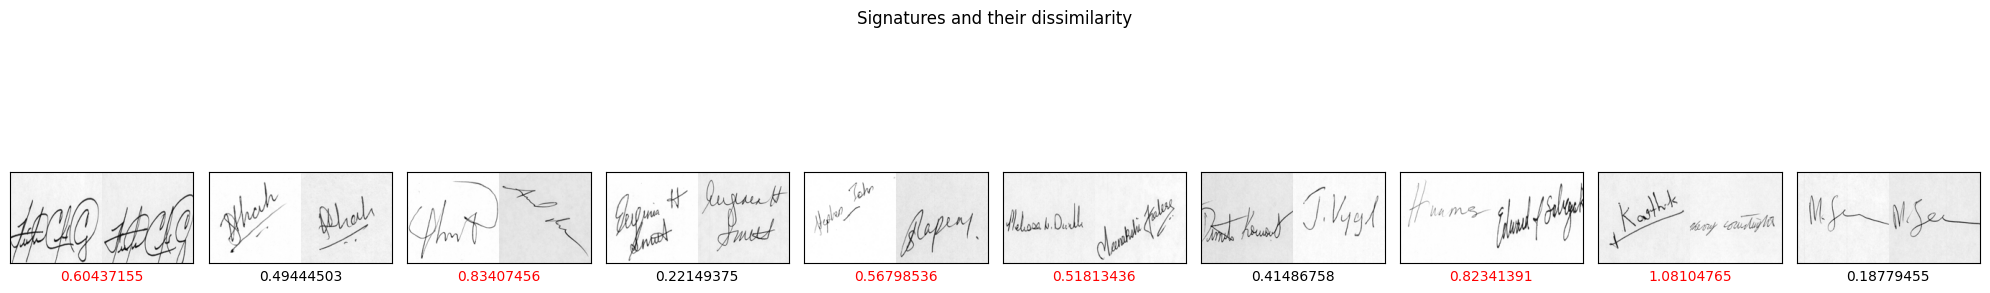

In [9]:
def display_predictions(pairs, predictions, num_samples=10):
    plt.figure(figsize=(20, 4))
    plt.suptitle("Signatures and their dissimilarity")

    for i in range(num_samples):
        # Extract the two signatures
        img1 = pairs[i, 0]
        img2 = pairs[i, 1]

        # Concatenate them side-by-side for plotting
        concat_img = np.concatenate((img1, img2), axis=1)

        ax = plt.subplot(1, num_samples, i + 1)
        plt.imshow(concat_img.squeeze(), cmap='gray')
        plt.xticks([])
        plt.yticks([])

        # Get the distance score and set color based on a 0.5 threshold
        dist = predictions[i][0]
        color = 'red' if dist > 0.5 else 'black'

        # Display the score under the image
        ax.set_xlabel(f"{dist:.8f}", color=color)

    plt.tight_layout()
    plt.show()

# Generate predictions for the first 10 test pairs
y_pred = model.predict([ts_pairs[:10, 0], ts_pairs[:10, 1]])

# Plot the results
display_predictions(ts_pairs, y_pred, num_samples=10)

Heatmap for Signature 1:


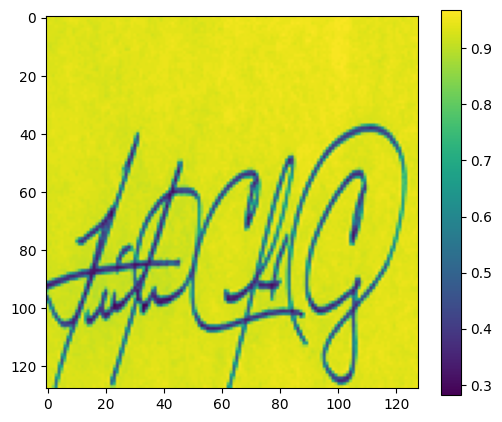

Heatmap for Signature 2:


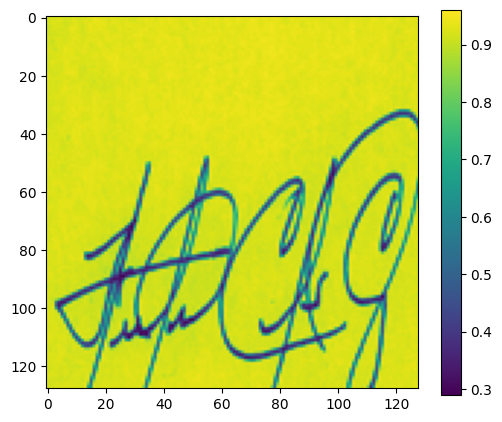

In [10]:
def plot_signature_heatmap(image):
    """
    Plots the signature using the viridis colormap to visualize
    pixel intensity and stroke focus areas.
    """
    plt.figure(figsize=(6, 5))
    # Squeeze removes the channel dimension (128, 128, 1) -> (128, 128)
    plt.imshow(image.squeeze(), cmap='viridis')
    plt.colorbar()
    plt.show()

# Display heatmaps for the first pair of testing signatures
print("Heatmap for Signature 1:")
plot_signature_heatmap(ts_pairs[0, 0])

print("Heatmap for Signature 2:")
plot_signature_heatmap(ts_pairs[0, 1])